In [3]:
import pickle
import matplotlib.pyplot as plt
import japanize_matplotlib
import numpy as np
from sklearn.svm import SVC
from pathlib import Path
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
import pandas as pd
import seaborn as sns

In [4]:
# data_file_path = "../data/20250512/processed/ishii_merged.pkl"
data_file_path = Path("../../data/20250604/processed/20250604_1_ishii_ica_epochs.pkl")
# data_file_path = "../../data/bcidatasetIV2a/processed/merged.pkl"

In [5]:
# pickleのEEGデータを読み込む
with open(data_file_path, 'rb') as f:
    data = pickle.load(f)

epochs = data['epochs'] # エポックデータ
epochs_list = epochs.get_data()  # エポックデータをリスト形式で取得
labels = data['labels']  # ラベル
# drop_indices = data['drop_indices']  # 除外されたエポックのインデックス
fs = epochs.info['sfreq']  # サンプリング周波数

In [6]:
ch_map = list(enumerate(epochs.info["ch_names"]))
ch_map

[(0, 'Fp1'),
 (1, 'Fz'),
 (2, 'F3'),
 (3, 'F7'),
 (4, 'FT9'),
 (5, 'FC5'),
 (6, 'FC1'),
 (7, 'C3'),
 (8, 'T7'),
 (9, 'TP9'),
 (10, 'CP5'),
 (11, 'CP1'),
 (12, 'Pz'),
 (13, 'P3'),
 (14, 'P7'),
 (15, 'O1'),
 (16, 'Oz'),
 (17, 'O2'),
 (18, 'P4'),
 (19, 'P8'),
 (20, 'TP10'),
 (21, 'CP6'),
 (22, 'CP2'),
 (23, 'Cz'),
 (24, 'C4'),
 (25, 'T8'),
 (26, 'FT10'),
 (27, 'FC6'),
 (28, 'FC2'),
 (29, 'F4'),
 (30, 'F8'),
 (31, 'Fp2'),
 (32, 'AF7'),
 (33, 'AF3'),
 (34, 'AFz'),
 (35, 'F1'),
 (36, 'F5'),
 (37, 'FT7'),
 (38, 'FC3'),
 (39, 'C1'),
 (40, 'C5'),
 (41, 'TP7'),
 (42, 'CP3'),
 (43, 'P1'),
 (44, 'P5'),
 (45, 'PO7'),
 (46, 'PO3'),
 (47, 'POz'),
 (48, 'PO4'),
 (49, 'PO8'),
 (50, 'P6'),
 (51, 'P2'),
 (52, 'CPz'),
 (53, 'CP4'),
 (54, 'TP8'),
 (55, 'C6'),
 (56, 'C2'),
 (57, 'FC4'),
 (58, 'FT8'),
 (59, 'F6'),
 (60, 'AF8'),
 (61, 'AF4'),
 (62, 'F2')]

In [7]:
use_chs = ["C5","C1","C2","C6","CP3","CP4"]
use_chs_idx = [epochs.info["ch_names"].index(ch) for ch in use_chs]
use_chs_idx

[40, 39, 56, 55, 42, 53]

In [8]:
# 例: axis=1で2, 4, 7番目の要素のみを選択する場合
# selected_indices = [2, 4, 7]
# epochs_selected = epochs_list[:, selected_indices, :]
# print(f"元の形状: {epochs_list.shape}")
# print(f"選択後の形状: {epochs_selected.shape}")

# または、チャンネル名で指定する場合
use_chs = ["C5","C1","C2","C6","CP3","CP4"]
use_chs_idx = [epochs.info["ch_names"].index(ch) for ch in use_chs]
use_chs_idx

[40, 39, 56, 55, 42, 53]

In [9]:
# labelsが9999のものを除外する
valid_indices = np.where(labels != 9999)[0]
# epochs_list = epochs_list[valid_indices]
labels = labels[valid_indices]

In [10]:
epochs_list.shape

(60, 63, 12501)

In [11]:
labels.shape

(60,)

In [12]:
# 1チャンネルのデータをDFTしてバンドパスパワーを計算
def calc_spectrum(data, band_count, fs):
    n = len(data)
    freq = np.fft.fftfreq(n, 1/fs)
    spectrum = np.fft.fft(data)
    # 1Hz-40Hzまでの4Hzごとのバンドパスパワーを計算
    band_lower = 0
    band_upper = 40
    band_powers = [None] * band_count
    for i in range(band_count):
        band = band_lower+i*(band_upper-band_lower)/band_count, band_lower+(i+1)*(band_upper-band_lower)/band_count
        band_power = np.sum(np.abs(spectrum[(freq >= band[0]) & (freq < band[1])])**2)
        band_powers[i] = band_power
    
    # band_powersの中にNoneがないことをassert
    # assert all([v is not None for v in band_powers]), "Some band powers are None"
    assert all(band_powers), "Some band powers are None"
    return band_powers

In [13]:
# 時間方向を6等分し、それぞれのウィンドウでFFTを計算する関数
def calc_windowed_spectrum(data, band_count, fs, window_count=6):
    n = len(data)
    window_size = n // window_count
    all_band_powers = []
    
    for i in range(window_count):
        # ウィンドウの開始位置と終了位置を計算
        start_idx = i * window_size
        end_idx = (i + 1) * window_size if i < window_count - 1 else n
        
        # 現在のウィンドウのデータを取得
        window_data = data[start_idx:end_idx]
        
        # 現在のウィンドウでFFTを計算
        window_band_powers = calc_spectrum(window_data, band_count, fs)
        
        # 結果を追加
        all_band_powers.extend(window_band_powers)
    
    return all_band_powers

In [14]:
e0 = epochs_list[0, :, :]
e0c0 = epochs_list[0, 0, :]
e0c0

array([-9.30949766e-06, -9.46138806e-06, -9.58895937e-06, ...,
       -3.94677566e-06, -3.60453253e-06, -3.26022334e-06])

In [15]:
calc_windowed_spectrum(e0c0, 10, fs, 6)

[1.242535434369619e-05,
 1.0502383360596686e-05,
 1.4796016375722655e-06,
 5.462735041935854e-06,
 4.7358764067470585e-06,
 8.18166113383729e-06,
 6.222603371592294e-06,
 2.5125538212769196e-06,
 2.0291127348277655e-06,
 2.8060544792405792e-06,
 4.769416837864079e-05,
 2.1792921153438558e-05,
 1.0027314516926653e-05,
 1.0504876281160157e-05,
 4.9205039658280455e-06,
 4.331992593991049e-06,
 8.901508188773155e-06,
 4.977574862009146e-06,
 3.897835454323283e-06,
 5.184962074495201e-06,
 4.5969957541769094e-05,
 1.0090804831398423e-05,
 6.056369702511395e-06,
 8.559708958297714e-06,
 2.6357008296091924e-06,
 6.918364873274471e-06,
 1.19813778839859e-05,
 2.2954091776450213e-06,
 3.2897223302473653e-06,
 4.210327348128307e-06,
 2.2126723446526438e-05,
 5.788705562404256e-06,
 5.572262019950528e-06,
 5.08431039876628e-06,
 1.0781039116787421e-05,
 1.4746787948709924e-05,
 9.023809831181437e-06,
 8.778222261292554e-06,
 1.285116577053922e-07,
 6.164636587214065e-06,
 3.498849609599876e-05,
 

In [16]:
# epochs_list[0]の各チャンネルのDFTを計算
def calc_spectrum_all_channels(epoch, band_count, fs, window_count=6):
    n_channels = epoch.shape[0]
    # 各チャンネルにつき、band_count × window_count の特徴量を格納するように変更
    band_powers = np.zeros((n_channels, band_count * window_count))
    for i in range(n_channels):
        band_powers[i] = calc_windowed_spectrum(epoch[i, :], band_count, fs, window_count)
    return band_powers

In [17]:
epochs_list

array([[[-9.30949766e-06, -9.46138806e-06, -9.58895937e-06, ...,
         -3.94677566e-06, -3.60453253e-06, -3.26022334e-06],
        [-6.61819783e-06, -6.67719987e-06, -6.72905247e-06, ...,
         -4.93273802e-06, -4.60791761e-06, -4.26894912e-06],
        [-1.14789266e-05, -1.14936513e-05, -1.15076565e-05, ...,
         -7.45696650e-06, -7.30558514e-06, -7.13490628e-06],
        ...,
        [-8.68024392e-06, -8.88847776e-06, -9.08003784e-06, ...,
         -7.44699476e-06, -7.11538511e-06, -6.76824569e-06],
        [ 7.86079327e-06,  7.66818884e-06,  7.43821140e-06, ...,
         -5.81038970e-06, -5.01818565e-06, -4.21080287e-06],
        [-4.35543682e-06, -4.40796432e-06, -4.45664434e-06, ...,
         -5.51612633e-06, -5.00906389e-06, -4.48585655e-06]],

       [[-4.64347313e-06, -4.64497821e-06, -4.66000783e-06, ...,
         -3.24555059e-06, -3.00362235e-06, -2.74540713e-06],
        [ 5.66985197e-06,  5.74854965e-06,  5.79338440e-06, ...,
         -1.77540176e-06, -1.79361111e

In [18]:
from tqdm.notebook import tqdm
from joblib import Parallel, delayed
import multiprocessing

print(use_chs)
band_count = 10
window_count = 3

time_start = int(fs)
time_end = time_start+int(fs*3)

# 特徴量の次元を更新（window_count倍に）
# all_epochs_band_powers = np.zeros((epochs_list.shape[0], epochs_list.shape[1], band_count * window_count))
all_epochs_band_powers = np.zeros((epochs_list.shape[0], 63, band_count * window_count))

# 各エポックを処理する関数
def process_epoch(i):
    # return calc_spectrum_all_channels(epochs_list[i, use_chs_idx, :], band_count, fs, window_count)
    return calc_spectrum_all_channels(epochs_list[i, :, time_start:time_end], band_count, fs, window_count)

# 使用するCPUコア数を設定（-1は全コアを使用）
n_jobs = multiprocessing.cpu_count()
print(f"使用するCPUコア数: {n_jobs}")

# tqdmでプログレスバーを表示しながら並列処理
results = Parallel(n_jobs=n_jobs, verbose=0)(
    delayed(process_epoch)(i) for i in tqdm(range(epochs_list.shape[0]), desc='エポック処理中')
)

# 結果を配列に格納
for i, result in enumerate(results):
    all_epochs_band_powers[i] = result

print(all_epochs_band_powers)
all_epochs_band_powers.shape

['C5', 'C1', 'C2', 'C6', 'CP3', 'CP4']
使用するCPUコア数: 8


エポック処理中:   0%|          | 0/60 [00:00<?, ?it/s]

[[[9.96926312e-05 2.60328775e-05 1.20472378e-05 ... 9.07373748e-06
   4.48683712e-06 7.08162969e-06]
  [1.00870844e-04 2.57521189e-05 1.63642226e-05 ... 9.54613004e-06
   6.09075387e-06 9.92428007e-06]
  [8.96367022e-05 2.83761516e-05 1.60819605e-05 ... 9.76586510e-06
   9.96579605e-06 8.81990857e-06]
  ...
  [2.71778157e-05 1.32749009e-05 6.82009127e-06 ... 1.03290433e-05
   2.36940252e-06 2.07722132e-06]
  [2.84455428e-04 1.60247264e-05 2.36476155e-05 ... 2.14092990e-05
   1.17625380e-05 2.95146354e-05]
  [1.07227358e-04 2.20828445e-05 1.42142537e-05 ... 1.22915347e-05
   7.52232369e-06 1.03024715e-05]]

 [[1.63096908e-04 1.41455440e-05 4.46840144e-06 ... 4.00680324e-07
   5.08876915e-06 7.82065897e-06]
  [1.69173931e-04 2.02049467e-05 1.13511260e-05 ... 2.19240701e-06
   4.70972046e-06 5.78278395e-06]
  [1.76989201e-04 1.53299336e-05 1.13771008e-05 ... 3.83562795e-06
   4.37345138e-06 5.88297670e-06]
  ...
  [1.41033360e-04 1.20646517e-05 8.35234493e-06 ... 1.62545697e-05
   3.56624

(60, 63, 30)

In [19]:
# all_epochs_band_powersをpickleで保存
# data_file_pathと同じディレクトリにサフィックスをつけて保存
output_file_path = data_file_path.parent / (data_file_path.stem + '_band_powers.pkl')
with open(output_file_path, 'wb') as f:
    pickle.dump({
        'band_powers': all_epochs_band_powers,
        'labels': labels,
        'fs': fs,
        'use_chs': use_chs,
        'use_chs_idx': use_chs_idx
    }, f)
print(f"特徴量を保存しました: {output_file_path}")

特徴量を保存しました: ../../data/20250604/processed/20250604_1_ishii_ica_epochs_band_powers.pkl


In [20]:
# ラベルの分布を確認
unique_labels, label_counts = np.unique(labels, return_counts=True)
print(f"ラベル分布: {dict(zip(unique_labels, label_counts))}")

# 各ラベルの色を定義
colors = ['red', 'blue', 'green', 'orange', 'purple']
label_colors = {label: colors[i % len(colors)] for i, label in enumerate(unique_labels)}

ラベル分布: {1: 30, 2: 30}


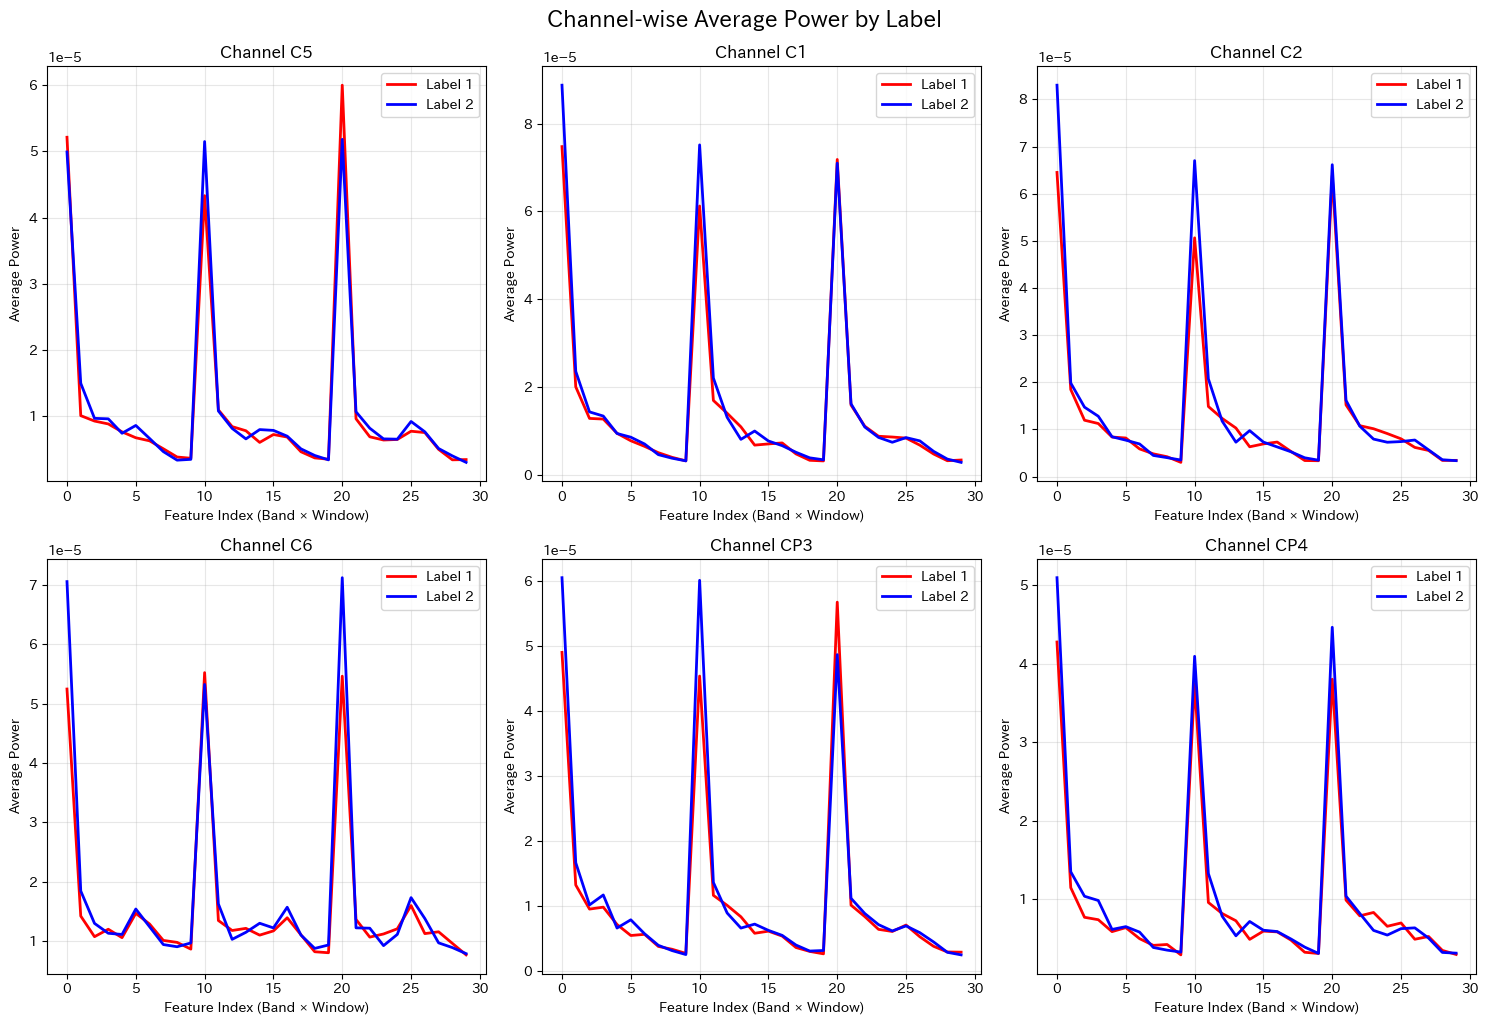

In [21]:
# 1. 使用チャンネルの平均パワーをラベル別に可視化
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, ch_idx in enumerate(use_chs_idx):
    ch_name = use_chs[i]
    ax = axes[i]
    
    for label in unique_labels:
        # 該当ラベルのデータを抽出
        label_mask = labels == label
        ch_data = all_epochs_band_powers[label_mask, ch_idx, :]  # (n_epochs, 30)
        
        # 全特徴量の平均を計算
        mean_powers = np.mean(ch_data, axis=0)
        
        # プロット
        ax.plot(mean_powers, label=f'Label {label}', color=label_colors[label], linewidth=2)
    
    ax.set_title(f'Channel {ch_name}')
    ax.set_xlabel('Feature Index (Band × Window)')
    ax.set_ylabel('Average Power')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle('Channel-wise Average Power by Label', fontsize=16, y=1.02)
plt.show()

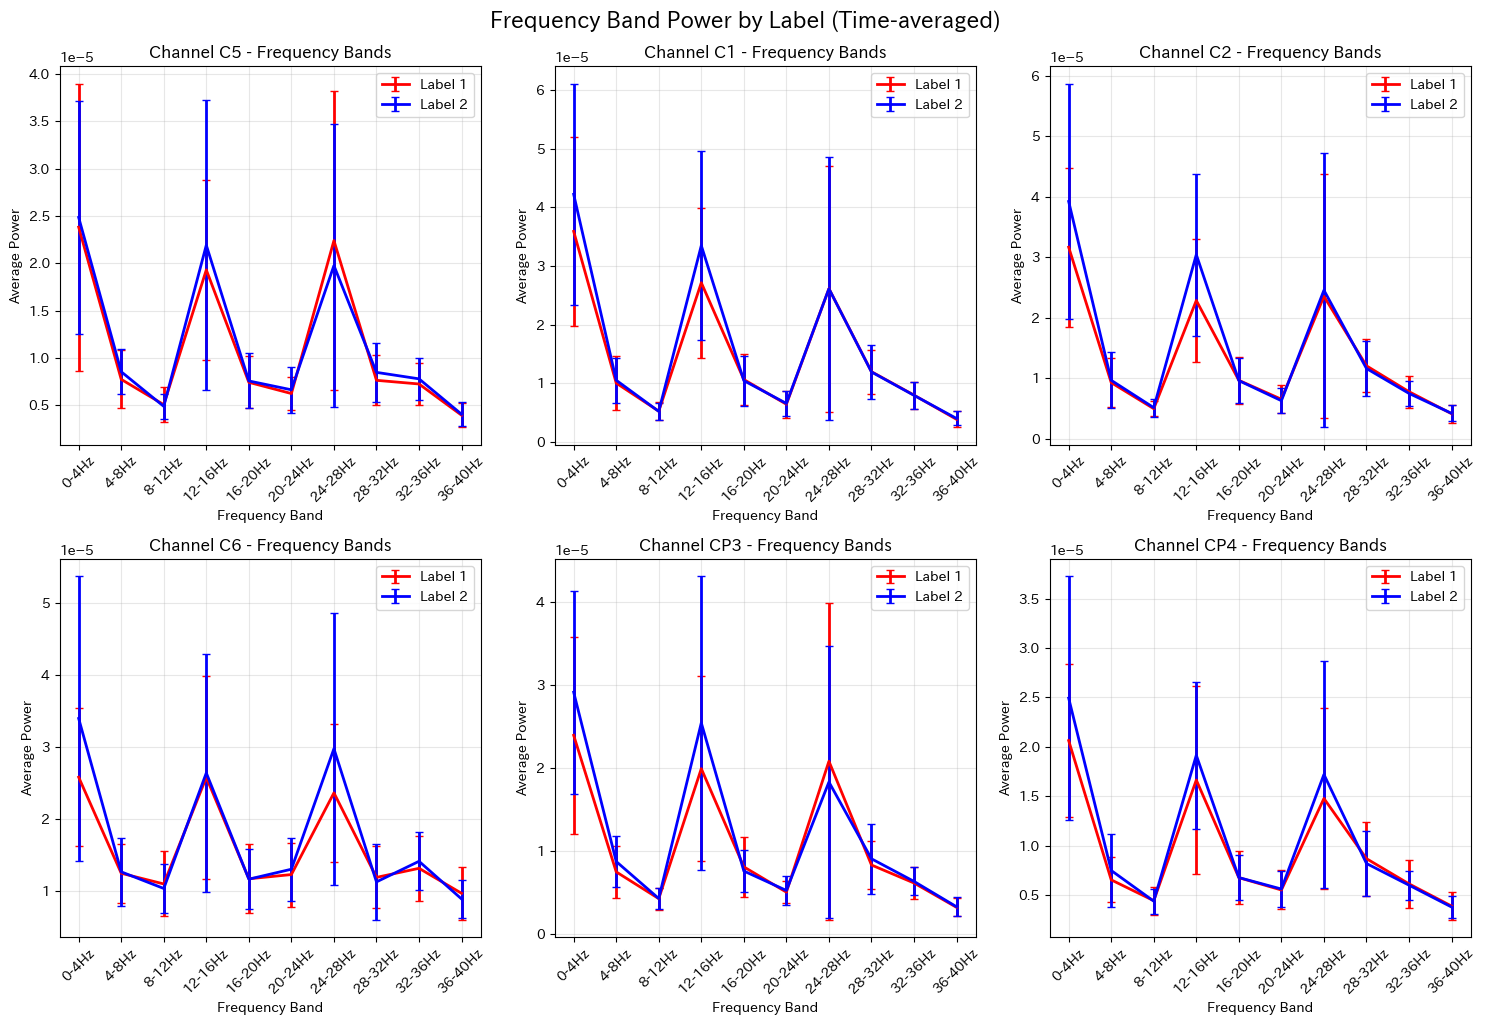

In [22]:
# 2. 周波数帯域別の比較（時間窓を平均化）
# 30次元の特徴量を(10 bands, 3 windows)に reshape
reshaped_powers = all_epochs_band_powers.reshape(60, 63, 10, 3)

# 時間窓を平均化して周波数帯域のみの特徴量を取得
band_powers_avg = np.mean(reshaped_powers, axis=3)  # (60, 63, 10)

# 周波数帯域名を定義
band_names = [f'{i*4}-{(i+1)*4}Hz' for i in range(10)]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, ch_idx in enumerate(use_chs_idx):
    ch_name = use_chs[i]
    ax = axes[i]
    
    for label in unique_labels:
        label_mask = labels == label
        ch_data = band_powers_avg[label_mask, ch_idx, :]  # (n_epochs, 10)
        
        # 各周波数帯域の平均パワー
        mean_band_powers = np.mean(ch_data, axis=0)
        std_band_powers = np.std(ch_data, axis=0)
        
        # エラーバー付きプロット
        ax.errorbar(range(10), mean_band_powers, yerr=std_band_powers, 
                   label=f'Label {label}', color=label_colors[label], 
                   linewidth=2, capsize=3)
    
    ax.set_title(f'Channel {ch_name} - Frequency Bands')
    ax.set_xlabel('Frequency Band')
    ax.set_ylabel('Average Power')
    ax.set_xticks(range(10))
    ax.set_xticklabels(band_names, rotation=45)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle('Frequency Band Power by Label (Time-averaged)', fontsize=16, y=1.02)
plt.show()

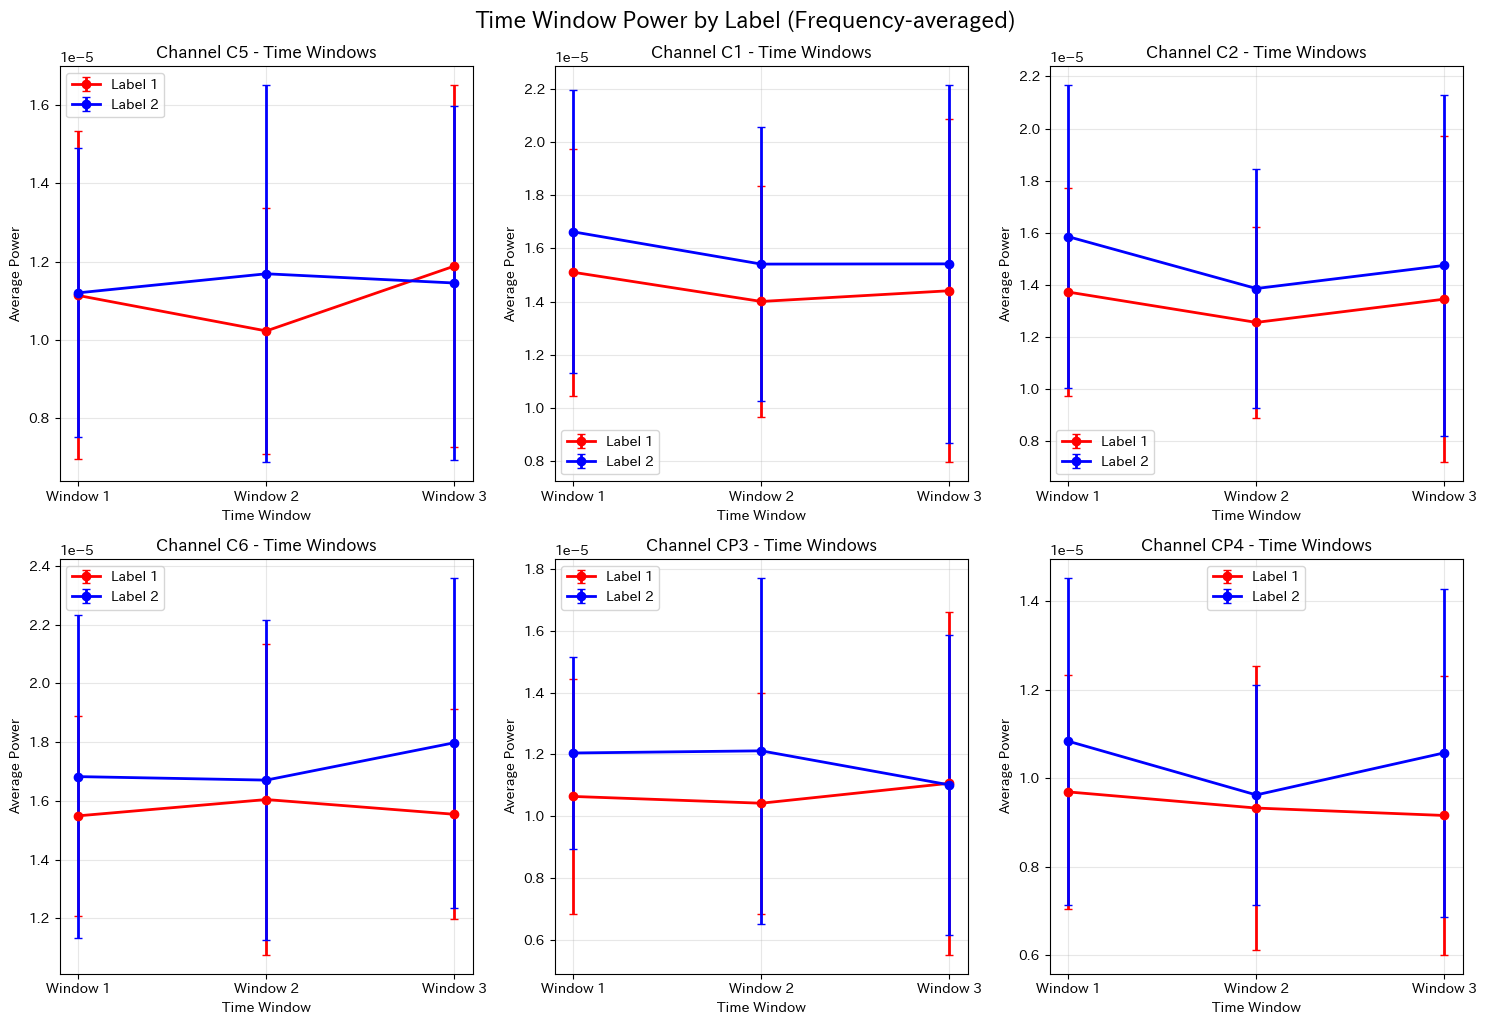

In [23]:
# 3. 時間窓別の比較（周波数帯域を平均化）
# 周波数帯域を平均化して時間窓のみの特徴量を取得
window_powers_avg = np.mean(reshaped_powers, axis=2)  # (60, 63, 3)

# 時間窓名を定義
window_names = ['Window 1', 'Window 2', 'Window 3']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, ch_idx in enumerate(use_chs_idx):
    ch_name = use_chs[i]
    ax = axes[i]
    
    for label in unique_labels:
        label_mask = labels == label
        ch_data = window_powers_avg[label_mask, ch_idx, :]  # (n_epochs, 3)
        
        # 各時間窓の平均パワー
        mean_window_powers = np.mean(ch_data, axis=0)
        std_window_powers = np.std(ch_data, axis=0)
        
        # エラーバー付きプロット
        ax.errorbar(range(3), mean_window_powers, yerr=std_window_powers, 
                   label=f'Label {label}', color=label_colors[label], 
                   linewidth=2, capsize=3, marker='o')
    
    ax.set_title(f'Channel {ch_name} - Time Windows')
    ax.set_xlabel('Time Window')
    ax.set_ylabel('Average Power')
    ax.set_xticks(range(3))
    ax.set_xticklabels(window_names)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle('Time Window Power by Label (Frequency-averaged)', fontsize=16, y=1.02)
plt.show()

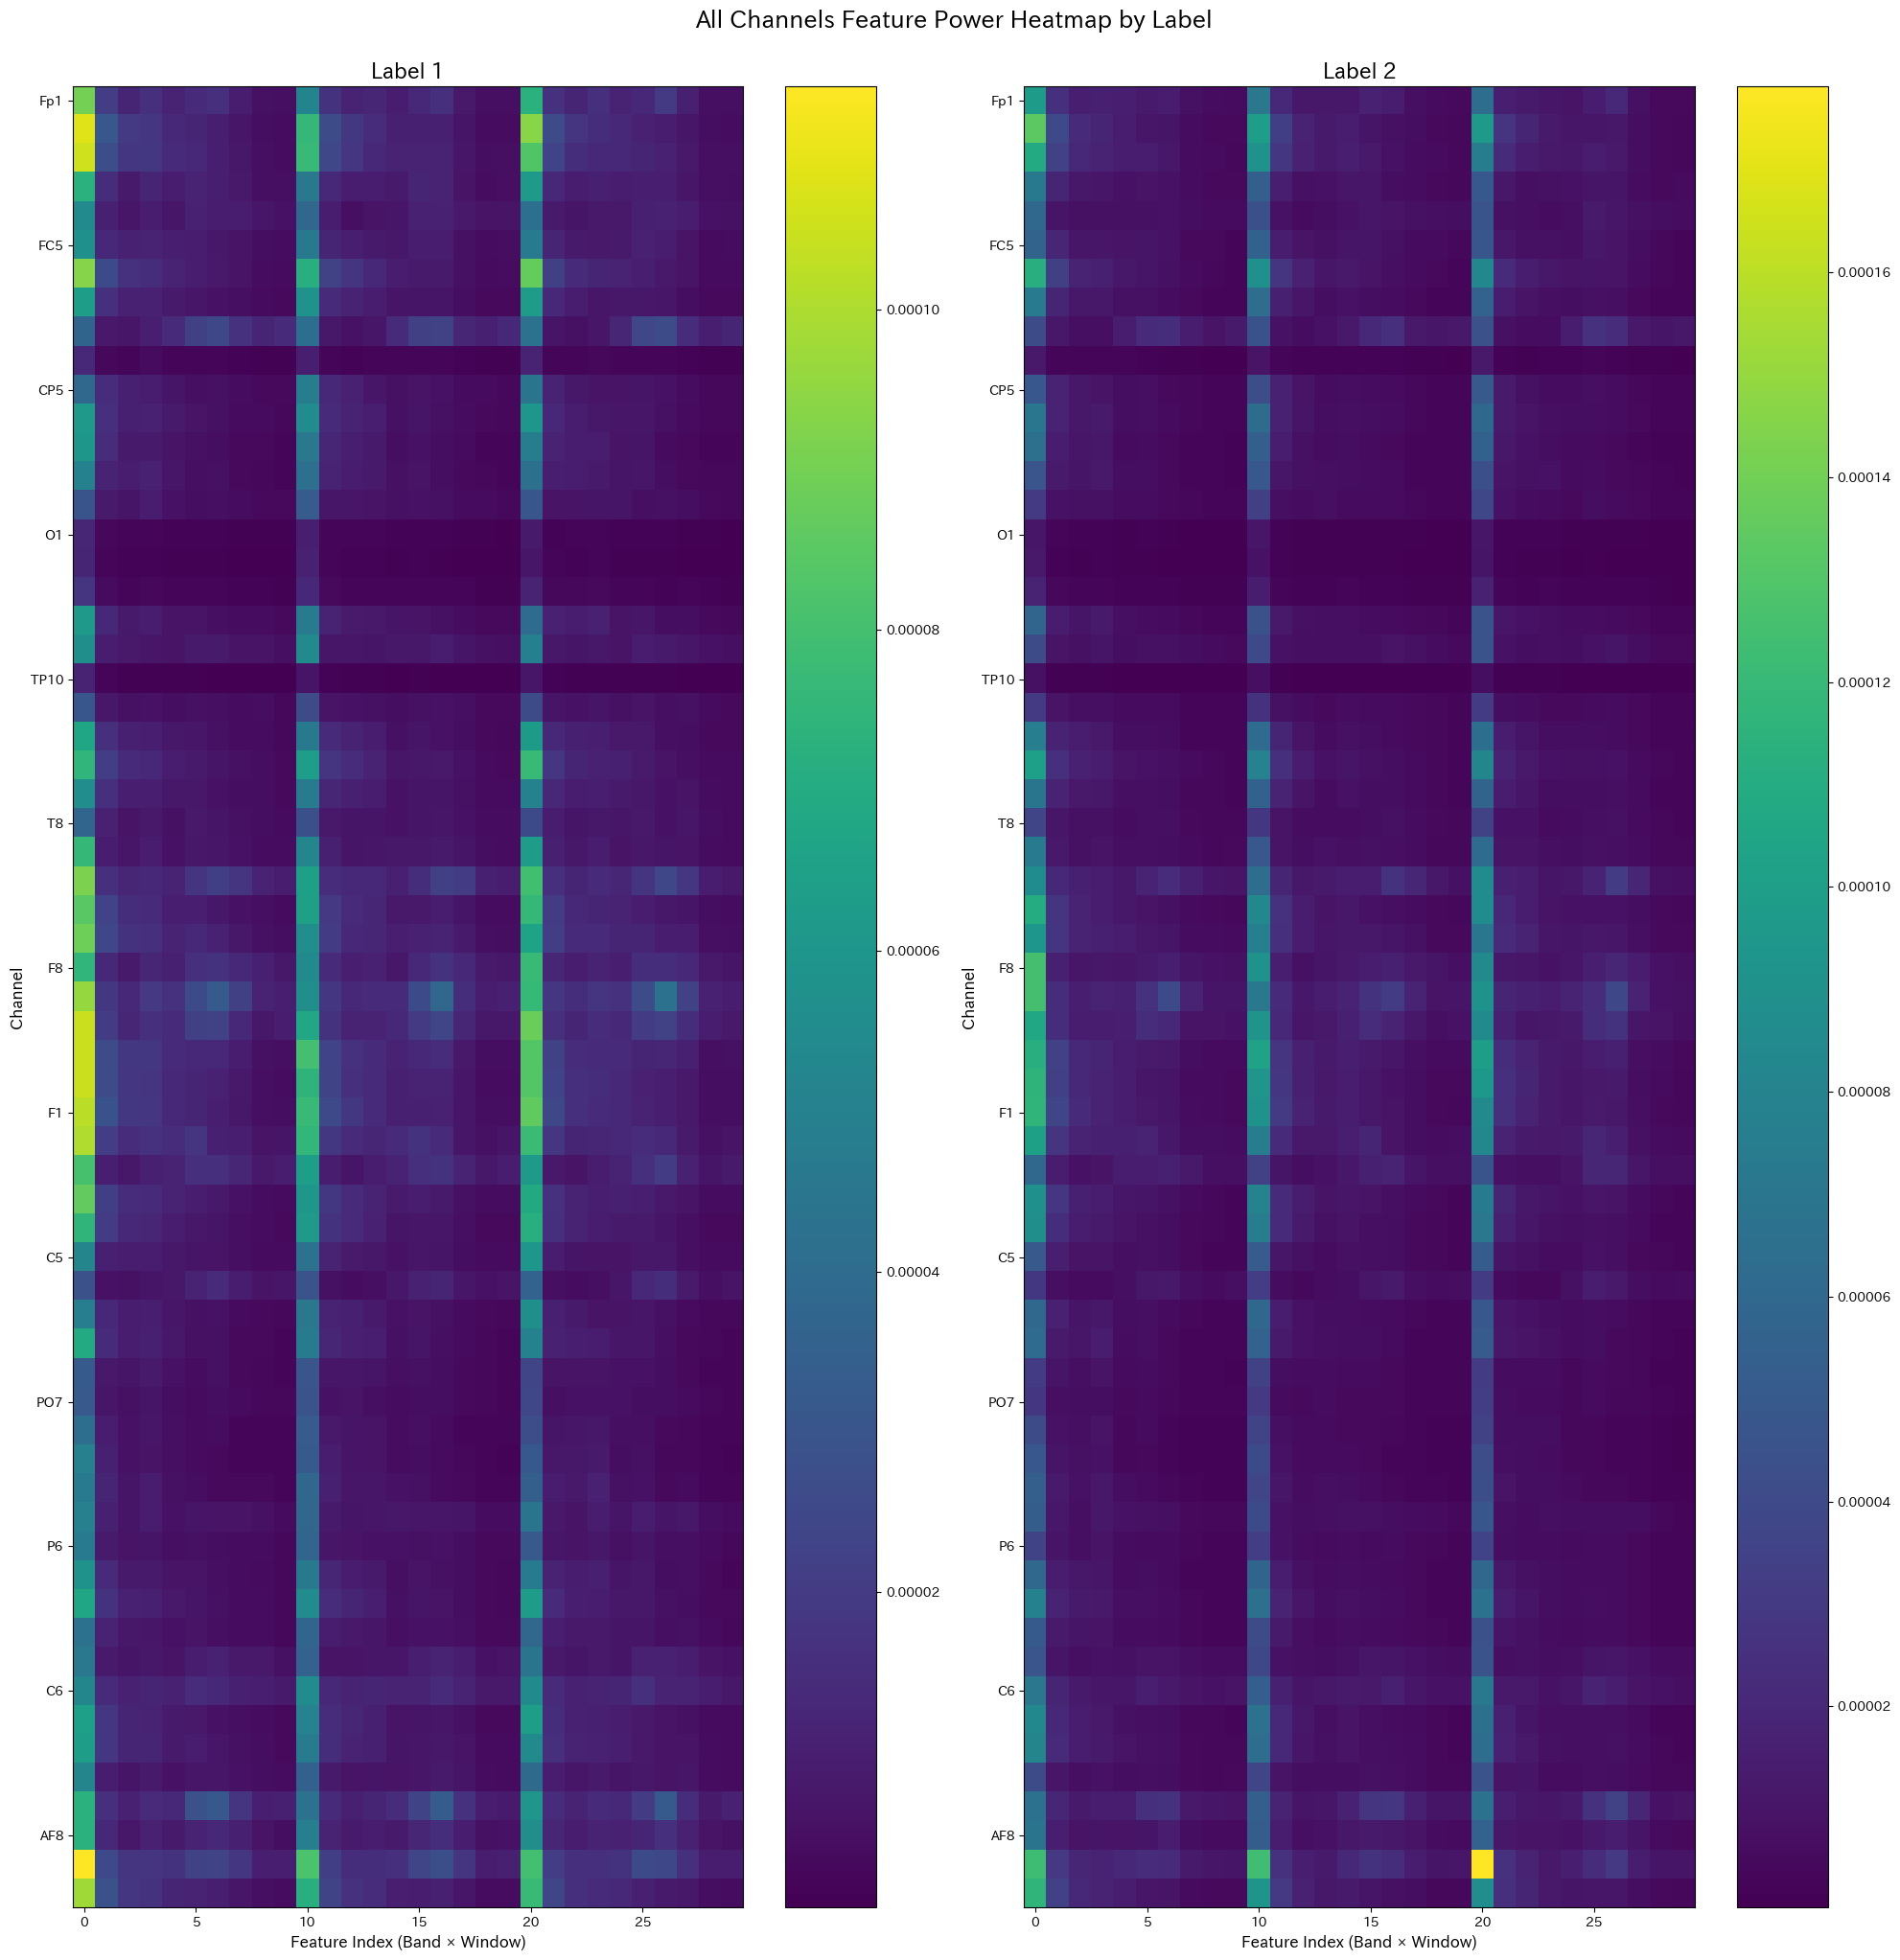

In [24]:
# 4. 全チャンネルのヒートマップによる全体的な傾向の可視化
# 各ラベルでの平均パワーを計算
label_mean_powers = {}
for label in unique_labels:
    label_mask = labels == label
    # 全チャンネルを使用
    label_data = all_epochs_band_powers[label_mask, :, :]
    label_mean_powers[label] = np.mean(label_data, axis=0)  # (63_channels, 30_features)

# サブプロット作成
n_labels = len(unique_labels)
fig, axes = plt.subplots(1, n_labels, figsize=(10*n_labels, 20))
if n_labels == 1:
    axes = [axes]

for i, label in enumerate(unique_labels):
    # ヒートマップ表示
    im = axes[i].imshow(label_mean_powers[label], aspect='auto', cmap='viridis')
    axes[i].set_title(f'Label {label}', fontsize=16)
    axes[i].set_xlabel('Feature Index (Band × Window)', fontsize=12)
    axes[i].set_ylabel('Channel', fontsize=12)
    axes[i].set_yticks(range(0, 63, 5))
    axes[i].set_yticklabels([epochs.info["ch_names"][j] for j in range(0, 63, 5)], fontsize=10)
    
    # カラーバー追加
    plt.colorbar(im, ax=axes[i])

plt.tight_layout()
plt.suptitle('All Channels Feature Power Heatmap by Label', fontsize=18, y=1.02)
plt.show()